# Mode-Switching Trigger Conditions

A trigger condition is a predicate that watches agent state and signals when a mode change is appropriate. Without triggers, mode switching is either hardcoded (inflexible) or left to the LLM's judgment (unpredictable). Explicit triggers give us both adaptability and auditability: the same context always produces the same routing decision, and every mode change has a named, logged reason.

The pattern is simple. On each turn, one or more trigger functions each receive a snapshot of the current agent state - the active mode, the incoming message, and a handful of operational metrics - and return a result describing whether they fired, what mode they recommend, and how urgent the switch is. When multiple triggers fire at once, a priority resolver picks the winner. The winning trigger's recommendation updates the mode before the LLM generates a response.

This notebook builds four trigger types from scratch - task-type, risk, user intent, and confidence - then assembles them into a priority resolver and a minimal agent loop. Each piece is demonstrated in isolation before being composed into the final agent.

In [1]:
import os
import re
from dataclasses import dataclass, field
from typing import Optional

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

## Initialize the language model
We initialize `ChatOpenAI` at `temperature=0`. Every trigger in this notebook is deterministic by design - the same context snapshot should always produce the same routing decision - so a zero-temperature LLM is important for the few places where an LLM call is used.

In [2]:
# temperature=0 ensures identical inputs always produce identical routing decisions
llm = ChatOpenAI(model="gpt-4o-mini", api_key=os.getenv("OPENAI_API_KEY", "").strip(), temperature=0)
print("LLM initialized:", llm.model_name)

LLM initialized: gpt-4o-mini


## Mode registry

Before building any trigger logic, we define the modes the agent can operate in. Each mode maps to a system prompt that fundamentally reshapes the LLM's behavior - structured and analytical for research, step-by-step for planning, cautious and approval-seeking for supervised work. These prompts are injected fresh on every turn rather than stored in conversation history, which means a mode change takes effect immediately on the next response with no conversation cleanup needed.

In [3]:
# System prompts define agent behavior when a mode is active — injected per call, not stored in history
MODE_PROMPTS: dict[str, str] = {
    "chat": (
        "You are a friendly general-purpose assistant. "
        "Keep responses warm, concise, and jargon-free."
    ),
    "research": (
        "You are a rigorous research assistant. "
        "Provide structured analyses with explicit reasoning and clear headings."
    ),
    "planning": (
        "You are a precise planning agent. "
        "Break every goal into numbered, actionable steps with effort estimates."
    ),
    "task_execution": (
        "You are a task-execution agent. "
        "Follow the approved plan step by step. Report each step's outcome."
    ),
    "supervised": (
        "You are operating in supervised mode. "
        "Pause before any irreversible action and explain what you intend to do "
        "and why human approval is required before you proceed."
    ),
}

print("Mode registry:", list(MODE_PROMPTS))

Mode registry: ['chat', 'research', 'planning', 'task_execution', 'supervised']


## Shared data types
Two shared types flow through every trigger function. `TriggerContext` is a snapshot of agent state at the moment a trigger is evaluated: the current mode, the incoming user message, risk metadata such as how many records an operation would affect, a failure rate counter, and a confidence score. Every trigger receives exactly this object and nothing else, keeping each function independently testable without a running agent.

`TriggerResult` is what every trigger returns. `fired` says whether the condition applied. `suggested_mode` is where to go if it did. `priority` determines which trigger wins when multiple fire on the same turn - lower numbers are more urgent. `auto_switch` encodes a safety asymmetry: reducing agent autonomy happens immediately, but increasing it requires explicit user confirmation before taking effect.

In [4]:
@dataclass
class TriggerContext:
    """Snapshot of agent state at the moment a trigger is evaluated.

    Every trigger function takes a TriggerContext and returns a TriggerResult.
    Keeping the input as a plain dataclass makes triggers independently testable.
    """
    current_mode:     str                                    # mode currently active
    user_message:     str                                    # incoming user message
    risk_metadata:    dict  = field(default_factory=dict)   # e.g. {"affected_records": 5000}
    failure_rate:     float = 0.0                           # fraction of recent steps that failed (0–1)
    confidence_score: float = 1.0                           # agent's self-reported certainty (0–1)


@dataclass
class TriggerResult:
    """Outcome of evaluating a single trigger condition."""
    fired:          bool
    trigger_name:   str
    suggested_mode: Optional[str] = None  # mode to switch to; None if trigger did not fire
    reason:         str  = ""             # human-readable explanation for audit logs
    priority:       int  = 99            # lower = more urgent; 99 is the safest default
    auto_switch:    bool = True           # False = requires human confirmation before switching


print("TriggerContext and TriggerResult defined")

TriggerContext and TriggerResult defined


`priority` defaults to 99 - the lowest possible urgency. A trigger that accidentally omits an explicit priority always loses to any properly prioritized trigger, which is the safe failure mode for conflict resolution. `field(default_factory=dict)` on `risk_metadata` is a Python dataclass requirement: mutable defaults must use a factory so each instance gets its own independent dict rather than all instances sharing one.

## Trigger 1 - Task-type detection
The first trigger watches the vocabulary of the user's message and infers which mode the current task belongs to. If that inferred mode differs from the one currently active, the trigger recommends a switch. A message that opens with "plan the deployment" belongs in planning mode even if the agent is currently in chat; a message that says "research the options" belongs in research mode even if the last step was executing code.

Signal phrases rather than an LLM call power this trigger. The tradeoff is speed and determinism over coverage: the same message always maps to the same mode, and unusual phrasings fall through to the `chat` fallback, which is the safest default when intent is unclear.

In [5]:
# Signal phrases for each mode — checked in order; first keyword match wins
TASK_TYPE_SIGNALS: dict[str, list[str]] = {
    "research": [
        "find out", "research", "look into", "what do you know about",
        "explain", "what is", "how does", "analyse", "overview", "compare",
    ],
    "planning": [
        "plan", "design", "architect", "how should i", "what steps",
        "roadmap", "schedule", "strategy", "approach", "how to",
    ],
    "task_execution": [
        "do it", "execute", "implement", "create", "build",
        "write the code", "now actually", "go ahead and",
    ],
    # 'chat' is the implicit fallback — no signal phrases needed
}


def _infer_task_type(message: str) -> str:
    """Return the best-fit mode for a message, or 'chat' if no signals match."""
    lower = message.lower()
    # Dict iteration order is insertion order — first match wins, so ordering matters
    for mode, signals in TASK_TYPE_SIGNALS.items():
        if any(sig in lower for sig in signals):
            return mode
    return "chat"  # safe fallback when nothing matches


def evaluate_task_type(ctx: TriggerContext) -> TriggerResult:
    """Fire when the inferred task type differs from the current mode.

    Switching into task_execution has auto_switch=False because it grants the agent authority to take actions — the user should explicitly confirm that grant.
    All other task-type shifts adjust communication style, not agent autonomy, so they apply automatically.
    """
    inferred = _infer_task_type(ctx.user_message)
    # Fire only when inferred mode differs from current AND is not the chat fallback
    # Without the second condition, any vague message would trigger a spurious switch to chat
    fired = (inferred != ctx.current_mode) and (inferred != "chat")
    return TriggerResult(
        fired=fired,
        trigger_name="task_type_change",
        suggested_mode=inferred if fired else None,
        reason=(
            f"Inferred '{inferred}' from message keywords; current mode is '{ctx.current_mode}'."
            if fired else
            f"No task-type shift detected (inferred '{inferred}')."
        ),
        priority=4,
        # task_execution requires confirmation — granting action authority needs explicit consent
        auto_switch=(inferred != "task_execution"),
    )


print("evaluate_task_type defined")

evaluate_task_type defined


In [6]:
task_type_cases = [
    TriggerContext(current_mode="chat",     user_message="Help me plan a database migration."),
    TriggerContext(current_mode="chat",     user_message="Go ahead and implement the migration script."),
    TriggerContext(current_mode="planning", user_message="What do you know about zero-downtime migrations?"),
    TriggerContext(current_mode="research", user_message="Tell me more about that."),  # chat fallback — no fire
]

print("TASK-TYPE TRIGGER")
print("=" * 70)
for ctx in task_type_cases:
    r = evaluate_task_type(ctx)
    status = "FIRED" if r.fired else "quiet"
    mode_col = f"→ {r.suggested_mode}" if r.suggested_mode else ""
    auto_col = f"  auto={r.auto_switch}" if r.fired else ""
    print(f"  [{status:<5}] {ctx.current_mode:<12} {mode_col:<22}{auto_col}")
    print(f"          msg: {ctx.user_message}")
    print(f"          {r.reason}")
    print()

TASK-TYPE TRIGGER
  [FIRED] chat         → planning              auto=True
          msg: Help me plan a database migration.
          Inferred 'planning' from message keywords; current mode is 'chat'.

  [FIRED] chat         → task_execution        auto=False
          msg: Go ahead and implement the migration script.
          Inferred 'task_execution' from message keywords; current mode is 'chat'.

  [FIRED] planning     → research              auto=True
          msg: What do you know about zero-downtime migrations?
          Inferred 'research' from message keywords; current mode is 'planning'.

  [quiet] research                           
          msg: Tell me more about that.
          No task-type shift detected (inferred 'chat').



The trigger fires only when the inferred mode differs from the current mode *and* is not the `chat` fallback. The second condition matters: without it, any vague message that matches no keywords would appear to trigger a switch back to `chat` - disruptive if the agent is mid-task in a specialized mode. The `auto_switch=False` for `task_execution` is the practical expression of the principle that granting more agent authority requires explicit consent; adjusting communication style does not.

## Trigger 2 - Risk escalation
The risk trigger watches for four conditions that all warrant escalating to supervised mode: a destructive keyword in the message, a high-scope operation that would affect many records, personally identifiable information in the message, and a high failure rate in recent steps. All four share priority 1 - the highest urgency in the system - so this trigger always beats every other trigger when they fire on the same turn.

Unlike the task-type trigger, risk escalation is not about adapting to what the user is trying to do. It is a safety mechanism: when any of these signals appear, the agent should pause and involve a human reviewer before taking any further action.

In [7]:
# Keywords indicating destructive or irreversible operations — checked against the user message
IRREVERSIBLE_KEYWORDS: list[str] = [
    "delete all", "drop table", "rm -rf", "wipe", "truncate", "destroy", "purge", "overwrite production", "format disk",
]

# Compiled once for efficiency — checked inline per turn, not per request
_PII_PATTERNS: list[re.Pattern] = [
    re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b"),  # email
    re.compile(r"\b\d{3}-\d{2}-\d{4}\b"),                                  # SSN
    re.compile(r"\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b"),                     # phone
]

HIGH_SCOPE_THRESHOLD   = 1_000  # records — above this, escalate regardless of operation type
FAILURE_RATE_THRESHOLD = 0.30   # fraction of recent steps — above this, something is going wrong


def evaluate_risk(ctx: TriggerContext) -> TriggerResult:
    """Fire when any of four risk signals are present; all escalate to supervised mode.

    Checks conditions in priority order and returns on the first match, so the audit reason is always precise — exactly one cause per fired result.
    """
    lower = ctx.user_message.lower()

    # Check 1: destructive keywords in message — immediate escalation
    matched = [kw for kw in IRREVERSIBLE_KEYWORDS if kw in lower]
    if matched:
        return TriggerResult(
            fired=True, trigger_name="irreversible_action",
            suggested_mode="supervised",
            reason=f"Destructive keywords detected: {matched}.",
            priority=1,  # highest urgency — risk overrides all other triggers
        )

    # Check 2: high-scope operation from risk_metadata — large blast radius warrants review
    affected = ctx.risk_metadata.get("affected_records", 0)
    if affected > HIGH_SCOPE_THRESHOLD:
        return TriggerResult(
            fired=True, trigger_name="high_scope_action",
            suggested_mode="supervised",
            reason=f"Operation affects {affected:,} records (threshold: {HIGH_SCOPE_THRESHOLD:,}).",
            priority=1,
        )

    # Check 3: PII in the user message — compliance requires supervised review
    if any(p.search(ctx.user_message) for p in _PII_PATTERNS):
        return TriggerResult(
            fired=True, trigger_name="pii_in_message",
            suggested_mode="supervised",
            reason="PII pattern detected — switching to supervised compliance mode.",
            priority=1,
        )

    # Check 4: high step-failure rate — repeated failures need human attention
    if ctx.failure_rate > FAILURE_RATE_THRESHOLD:
        return TriggerResult(
            fired=True, trigger_name="high_failure_rate",
            suggested_mode="supervised",
            reason=f"Step failure rate {ctx.failure_rate:.0%} exceeds threshold {FAILURE_RATE_THRESHOLD:.0%}.",
            priority=1,
        )

    return TriggerResult(fired=False, trigger_name="risk", reason="No risk signals.", priority=1)


print("evaluate_risk defined")
print(f"Thresholds: scope > {HIGH_SCOPE_THRESHOLD:,} records, failure_rate > {FAILURE_RATE_THRESHOLD:.0%}")

evaluate_risk defined
Thresholds: scope > 1,000 records, failure_rate > 30%


In [8]:
risk_cases = [
    TriggerContext(current_mode="task_execution",
                   user_message="Drop table orders from the production database."),
    TriggerContext(current_mode="task_execution",
                   user_message="Apply the discount to all users.",
                   risk_metadata={"affected_records": 5_000}),    # exceeds HIGH_SCOPE_THRESHOLD
    TriggerContext(current_mode="chat",
                   user_message="My email is alice@example.com — can you update my preferences?"),
    TriggerContext(current_mode="task_execution",
                   user_message="Continue with the next step.",
                   failure_rate=0.45),                             # exceeds FAILURE_RATE_THRESHOLD
    TriggerContext(current_mode="planning",
                   user_message="How should we structure the release?"),  # clean pass — no signals
]

print("RISK TRIGGER")
print("=" * 70)
for ctx in risk_cases:
    r = evaluate_risk(ctx)
    status = "FIRED" if r.fired else "quiet"
    print(f"  [{status:<5}] {r.trigger_name}")
    print(f"          msg: {ctx.user_message[:75]}")
    print(f"          {r.reason}")
    print()

RISK TRIGGER
  [FIRED] irreversible_action
          msg: Drop table orders from the production database.
          Destructive keywords detected: ['drop table'].

  [FIRED] high_scope_action
          msg: Apply the discount to all users.
          Operation affects 5,000 records (threshold: 1,000).

  [FIRED] pii_in_message
          msg: My email is alice@example.com — can you update my preferences?
          PII pattern detected — switching to supervised compliance mode.

  [FIRED] high_failure_rate
          msg: Continue with the next step.
          Step failure rate 45% exceeds threshold 30%.

  [quiet] risk
          msg: How should we structure the release?
          No risk signals.



All four sub-conditions share priority 1 - risk always overrides task-type, user intent, and confidence triggers. The function returns on the first condition that matches, so each fired result carries exactly one cause, making the audit reason precise. If a message contains both a destructive keyword and PII, only the irreversible-action check fires because it is evaluated first.

The user intent trigger covers the most common reason for a mode switch: the user says what they want explicitly. It handles two forms - slash commands and natural-language autonomy phrases - using pattern matching only, with no LLM call. Most explicit mode requests use one of a small set of standard phrasings that keywords catch reliably and cheaply.

## Trigger 3 - User intent
The user intent trigger handles the most direct form of mode switching: the user explicitly says what they want. Two forms are supported - slash commands like `/mode supervised` or `/research`, and natural-language phrases like "just do it" or "stop and ask me first". Both are matched with compiled patterns rather than an LLM call, keeping this trigger fast and free on every turn regardless of message length.

The key design decision is the `auto_switch` asymmetry. Requests to reduce the agent's autonomy are always honored immediately - the user is asking for more control, which is always safe to grant without confirmation. Requests to increase autonomy set `auto_switch=False` and require an explicit confirmation step before taking effect.

In [9]:
# Regex for the canonical /mode <name> command
_SLASH_RE = re.compile(r"^/mode\s+(\w+)", re.IGNORECASE)

# Shorthand slash commands — simpler to type than /mode <name>
_SLASH_SHORTHANDS: dict[str, str] = {
    "/research":   "research",
    "/plan":       "planning",
    "/supervised": "supervised",
    "/chat":       "chat",
    "/execute":    "task_execution",
}

# Phrases that signal the user wants the agent to act more autonomously
_AUTONOMY_UP_PHRASES: list[str] = [
    "just do it", "you have my approval", "proceed without asking",
    "go ahead autonomously", "don't ask me for confirmation",
]

# Phrases that signal the user wants more human oversight
_AUTONOMY_DOWN_PHRASES: list[str] = [
    "stop and ask", "check with me first", "don't do anything without my approval",
    "ask before every step", "pause and confirm",
]


def evaluate_user_intent(ctx: TriggerContext) -> TriggerResult:
    """Fire when the user explicitly requests a mode change via patterns or phrases."""
    msg   = ctx.user_message.strip()
    lower = msg.lower()

    # Layer 1: canonical /mode <name> command — highest confidence
    m = _SLASH_RE.match(msg)
    if m:
        requested = m.group(1).lower()
        if requested in MODE_PROMPTS:
            return TriggerResult(
                fired=True, trigger_name="slash_command",
                suggested_mode=requested,
                reason=f"Slash command '/mode {requested}' detected.",
                priority=3, auto_switch=True,
            )
        # Unknown mode name — signal the problem but don't auto-switch
        return TriggerResult(
            fired=True, trigger_name="slash_command_unknown",
            reason=f"Unknown mode '{requested}' in slash command.",
            priority=3, auto_switch=False,
        )

    # Layer 2: shorthand slash commands
    for shorthand, mode in _SLASH_SHORTHANDS.items():
        if lower.startswith(shorthand):
            return TriggerResult(
                fired=True, trigger_name="slash_command",
                suggested_mode=mode,
                reason=f"Shorthand command '{shorthand}' detected.",
                priority=3, auto_switch=True,
            )

    # Layer 3: autonomy increase — auto_switch=False because granting more power needs confirmation
    if any(phrase in lower for phrase in _AUTONOMY_UP_PHRASES):
        return TriggerResult(
            fired=True, trigger_name="autonomy_increase",
            suggested_mode="task_execution",
            reason="User requested increased autonomy; explicit confirmation required.",
            priority=3, auto_switch=False,
        )

    # Layer 4: autonomy decrease — always honored immediately, no confirmation needed
    if any(phrase in lower for phrase in _AUTONOMY_DOWN_PHRASES):
        return TriggerResult(
            fired=True, trigger_name="autonomy_decrease",
            suggested_mode="supervised",
            reason="User requested more human oversight; switching to supervised immediately.",
            priority=3, auto_switch=True,   # safe direction — never requires confirmation
        )

    return TriggerResult(fired=False, trigger_name="user_intent",
                         reason="No explicit user intent detected.", priority=3)


print("evaluate_user_intent defined.")

evaluate_user_intent defined.


In [10]:
intent_cases = [
    TriggerContext(current_mode="chat",           user_message="/mode supervised"),
    TriggerContext(current_mode="chat",           user_message="/research"),
    TriggerContext(current_mode="research",       user_message="Just do it, you have my approval."),
    TriggerContext(current_mode="task_execution", user_message="Stop and ask me before doing anything."),
    TriggerContext(current_mode="chat",           user_message="What do you think about this?"),
]

print("USER INTENT TRIGGER")
print("=" * 70)
for ctx in intent_cases:
    r = evaluate_user_intent(ctx)
    status   = "FIRED" if r.fired else "quiet"
    mode_col = f"→ {r.suggested_mode}" if r.suggested_mode else ""
    auto_col = f"  auto={r.auto_switch}" if r.fired else ""
    print(f"  [{status:<5}] {r.trigger_name:<25} {mode_col:<22}{auto_col}")
    print(f"          msg: {ctx.user_message}")
    print(f"          {r.reason}")
    print()

USER INTENT TRIGGER
  [FIRED] slash_command             → supervised            auto=True
          msg: /mode supervised
          Slash command '/mode supervised' detected.

  [FIRED] slash_command             → research              auto=True
          msg: /research
          Shorthand command '/research' detected.

  [FIRED] autonomy_increase         → task_execution        auto=False
          msg: Just do it, you have my approval.
          User requested increased autonomy; explicit confirmation required.

  [FIRED] autonomy_decrease         → supervised            auto=True
          msg: Stop and ask me before doing anything.
          User requested more human oversight; switching to supervised immediately.

  [quiet] user_intent                                     
          msg: What do you think about this?
          No explicit user intent detected.



Pattern matching handles the vast majority of explicit requests: most users either type a slash command or reach for one of a small set of standard autonomy phrases. The layered check - canonical `/mode` command first, then shorthands, then phrase lists - mirrors the order of specificity, so the most unambiguous signal is always tried first.

The `auto_switch` asymmetry is the key safety property here. Phrases that reduce autonomy (`"stop and ask"`, `"pause and confirm"`) take effect immediately without any confirmation step - the user is asking for more control, which is always safe to honor. Phrases that increase autonomy (`"just do it"`, `"you have my approval"`) set `auto_switch=False`, so the orchestration layer must present the proposed switch and wait for explicit confirmation before granting the agent more authority.

## Trigger 4 - Confidence threshold
The confidence trigger is different from the other three in that it does not examine the message content at all. It fires based entirely on a numeric score - `confidence_score` in `TriggerContext` - that the orchestration layer populates before each turn. When the agent's certainty in what to do next falls below a threshold, the trigger escalates to supervised mode rather than letting the agent proceed on shaky footing and likely fail.

The score can come from any source: token-level log probabilities, a self-assessment prompt, or an evaluation layer. The trigger itself is agnostic about how that score is produced - it only acts on the value, keeping the trigger lean and the scoring mechanism fully swappable.

In [11]:
LOW_CONFIDENCE_THRESHOLD = 0.70  # below this, agent uncertainty is too high to proceed unsupervised


def evaluate_confidence(ctx: TriggerContext) -> TriggerResult:
    """Fire when the agent's self-reported confidence falls below the safe threshold.

    The confidence_score comes from TriggerContext — it is set by the orchestration layer (e.g. from log-probability sampling or a self-assessment step) before each turn. This trigger never computes it; it only acts on it.
    """
    if ctx.confidence_score < LOW_CONFIDENCE_THRESHOLD:
        return TriggerResult(
            fired=True,
            trigger_name="low_confidence",
            suggested_mode="supervised",
            reason=(
                f"Agent confidence {ctx.confidence_score:.0%} is below "
                f"the {LOW_CONFIDENCE_THRESHOLD:.0%} threshold — "
                "escalating to supervised mode."
            ),
            priority=4,
            auto_switch=True,  # reducing autonomy is always safe to do immediately
        )

    return TriggerResult(
        fired=False,
        trigger_name="confidence",
        reason=f"Confidence {ctx.confidence_score:.0%} is within acceptable range.",
        priority=4,
    )


print("evaluate_confidence defined.")
print(f"Threshold: confidence_score < {LOW_CONFIDENCE_THRESHOLD:.0%}")

evaluate_confidence defined.
Threshold: confidence_score < 70%


In [12]:
confidence_cases = [
    # Well below threshold — fires immediately
    TriggerContext(
        current_mode="task_execution",
        user_message="Apply the schema migration to the production cluster.",
        confidence_score=0.55,
    ),
    # Just below threshold — also fires
    TriggerContext(
        current_mode="planning",
        user_message="Design the deployment pipeline.",
        confidence_score=0.68,
    ),
    # Above threshold — no trigger
    TriggerContext(
        current_mode="planning",
        user_message="Design a fault-tolerant microservices architecture for our payment system.",
        confidence_score=0.88,
    ),
    # Already in supervised mode with high confidence — trigger is quiet (escalation not needed)
    TriggerContext(
        current_mode="supervised",
        user_message="Run the nightly backup script.",
        confidence_score=0.95,
    ),
]

print("CONFIDENCE TRIGGER")
print("=" * 70)
for ctx in confidence_cases:
    r = evaluate_confidence(ctx)
    status = "FIRED" if r.fired else "quiet"
    print(f"  [{status:<5}]  confidence={ctx.confidence_score:.0%}  mode={ctx.current_mode}")
    print(f"          msg: {ctx.user_message}")
    print(f"          {r.reason}")
    print()

CONFIDENCE TRIGGER
  [FIRED]  confidence=55%  mode=task_execution
          msg: Apply the schema migration to the production cluster.
          Agent confidence 55% is below the 70% threshold — escalating to supervised mode.

  [FIRED]  confidence=68%  mode=planning
          msg: Design the deployment pipeline.
          Agent confidence 68% is below the 70% threshold — escalating to supervised mode.

  [quiet]  confidence=88%  mode=planning
          msg: Design a fault-tolerant microservices architecture for our payment system.
          Confidence 88% is within acceptable range.

  [quiet]  confidence=95%  mode=supervised
          msg: Run the nightly backup script.
          Confidence 95% is within acceptable range.



The confidence trigger is the simplest of the four: a single numeric comparison with no string matching, no regex, and no external calls. Because `confidence_score` is passed in via `TriggerContext`, the trigger itself has no opinion on how that score is computed - it only acts on the value. The threshold (0.70 here) is a tunable constant; in production it should be calibrated against observed error rates for each agent and task type.

With all four triggers defined, the next step is the priority resolver - a function that runs all four against the same context snapshot, collects whichever ones fired, and picks the highest-priority winner.

## Priority resolution
With four independent triggers that can each fire on the same turn, we need a single function that evaluates all of them and selects one winner. The rule is simple: the trigger with the lowest priority number wins. When two triggers share the same priority level - both task-type and confidence use priority 4 - their position in the evaluation list is the tiebreaker.

The resolver is fully deterministic: the same `TriggerContext` always produces the same winner, and the complete evaluation log is returned alongside the winner so every mode-change decision can be audited after the fact.

In [13]:
def evaluate_all_triggers(
    ctx: TriggerContext,
) -> tuple[Optional[TriggerResult], list[TriggerResult]]:
    """Evaluate all four triggers and return the highest-priority winner plus the full log.

    Returns:
        (winner_or_None, all_results) — winner is None if no trigger fired.
    """
    # Each trigger is evaluated independently against the same context snapshot
    all_results = [
        evaluate_risk(ctx),           # priority 1 — safety always wins
        evaluate_user_intent(ctx),    # priority 3 — explicit requests honored next
        evaluate_task_type(ctx),      # priority 4 — inferred task-type shifts
        evaluate_confidence(ctx),     # priority 4 — certainty checks
    ]

    fired = [r for r in all_results if r.fired]
    if not fired:
        return None, all_results   # no trigger fired — stay in current mode

    # Sort ascending: lowest priority number = most urgent
    # Python's sort is stable, so equal-priority triggers keep their list order as a tiebreaker
    fired.sort(key=lambda r: r.priority)
    winner = fired[0]
    return winner, all_results


print("evaluate_all_triggers defined.")

evaluate_all_triggers defined.


Priority order:
- 1 — risk        (safety overrides everything)
- 3 — user intent (explicit requests before inference)
- 4 — task-type   (inferred intent shifts)
- 4 — confidence  (certainty escalation — loses to task-type on tie)

In [14]:
# Scenarios where multiple triggers fire simultaneously — observe which one wins
conflict_cases = [
    # Scenario 1: risk + task-type both fire → risk (priority 1) should win
    TriggerContext(
        current_mode="chat",
        user_message="Help me plan to drop table orders from the production database.",
    ),
    # Scenario 2: user intent + task-type both fire → user intent (priority 3) should win
    TriggerContext(
        current_mode="research",
        user_message="/supervised — let's review each step before proceeding.",
    ),
    # Scenario 3: task-type + confidence both fire at the same priority → task-type wins (list order)
    TriggerContext(
        current_mode="chat",
        user_message="Build the entire infrastructure now.",
        confidence_score=0.50,
    ),
    # Scenario 4: nothing fires — stays in current mode
    TriggerContext(
        current_mode="research",
        user_message="Tell me more about that.",
        confidence_score=0.90,
    ),
]

print("CONFLICT RESOLUTION DEMO")
print("=" * 70)
for i, ctx in enumerate(conflict_cases, start=1):
    winner, all_results = evaluate_all_triggers(ctx)
    fired_results = [r for r in all_results if r.fired]
    print(f"\nScenario {i}: {ctx.user_message}")
    print(f"  current_mode={ctx.current_mode}  confidence={ctx.confidence_score:.0%}")
    if fired_results:
        print(f"  Fired triggers ({len(fired_results)}):")
        for r in sorted(fired_results, key=lambda x: x.priority):
            marker = "★ WINNER" if (winner and r.trigger_name == winner.trigger_name) else "       "
            print(f"    [{marker}] prio={r.priority}  {r.trigger_name:<28} → {r.suggested_mode}")
    else:
        print("  No triggers fired — remaining in current mode.")
    if winner:
        print(f"  Decision: switch to '{winner.suggested_mode}'  auto_switch={winner.auto_switch}")

CONFLICT RESOLUTION DEMO

Scenario 1: Help me plan to drop table orders from the production database.
  current_mode=chat  confidence=100%
  Fired triggers (2):
    [★ WINNER] prio=1  irreversible_action          → supervised
    [       ] prio=4  task_type_change             → planning
  Decision: switch to 'supervised'  auto_switch=True

Scenario 2: /supervised — let's review each step before proceeding.
  current_mode=research  confidence=100%
  Fired triggers (1):
    [★ WINNER] prio=3  slash_command                → supervised
  Decision: switch to 'supervised'  auto_switch=True

Scenario 3: Build the entire infrastructure now.
  current_mode=chat  confidence=50%
  Fired triggers (2):
    [★ WINNER] prio=4  task_type_change             → task_execution
    [       ] prio=4  low_confidence               → supervised
  Decision: switch to 'task_execution'  auto_switch=False

Scenario 4: Tell me more about that.
  current_mode=research  confidence=90%
  No triggers fired — remaining 

The sort on `priority` is stable in Python - when two triggers share the same priority number, they keep their original position in the list as a tiebreaker. That is why `evaluate_task_type` is listed before `evaluate_confidence`: in scenario 3 above, both fire at priority 4, and task-type wins because it appears earlier in the list. This ordering is part of the behavioral specification, not an implementation detail - it should be documented alongside the priority values.

## LangGraph agent with trigger-based routing
With all four triggers and the priority resolver in place, the last step is wiring everything into a LangGraph `StateGraph`. The graph makes trigger evaluation a first-class, visible step in the control flow rather than a side effect buried inside a response function. Every turn passes through `evaluate_triggers_node` before reaching `execute_in_mode_node`, and the winning trigger's mode recommendation is written to shared state between the two nodes.

```
START → evaluate_triggers_node → execute_in_mode_node → END
```

Below we define the `AgentState` TypedDict that carries mode metadata, operational metrics, and the trigger audit log across turns. LangGraph imports are grouped here where the graph section begins.

In [15]:
# LangGraph imports — added here where the graph section begins
from typing import Annotated, Sequence, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import Image, display


class AgentState(TypedDict):
    """State shared between the two graph nodes on every turn."""
    # add_messages reducer appends new messages rather than replacing the list
    messages:         Annotated[Sequence[BaseMessage], add_messages]
    current_mode:     str    # active mode — written by evaluate_triggers_node
    confidence_score: float  # consumed by evaluate_confidence trigger
    failure_rate:     float  # consumed by evaluate_risk (failure_rate check)
    risk_metadata:    dict   # consumed by evaluate_risk (scope check)
    trigger_log:      list   # accumulates fired trigger entries across turns


print("LangGraph imports and AgentState TypedDict defined.")

LangGraph imports and AgentState TypedDict defined.


In [16]:
def evaluate_triggers_node(state: AgentState) -> dict:
    """Node 1: build a TriggerContext from state, run all triggers, update the mode.

    Pure function — never calls the LLM, never modifies messages.
    Only 'current_mode' and 'trigger_log' are written back to state.
    """
    # Find the most recent human message to pass as user_message
    last_human = next(
        (m for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), None
    )

    ctx = TriggerContext(
        current_mode=state["current_mode"],
        user_message=last_human.content if last_human else "",
        failure_rate=state.get("failure_rate", 0.0),
        confidence_score=state.get("confidence_score", 1.0),
        risk_metadata=state.get("risk_metadata", {}),
    )

    winner, all_results = evaluate_all_triggers(ctx)
    # Use the winner's suggestion if one fired, otherwise stay in the current mode
    new_mode = winner.suggested_mode if (winner and winner.suggested_mode) else state["current_mode"]

    # Serialize fired triggers for the audit log
    new_entries = [
        {
            "trigger":        r.trigger_name,
            "suggested_mode": r.suggested_mode,
            "reason":         r.reason,
            "priority":       r.priority,
            "winner":         winner is not None and r.trigger_name == winner.trigger_name,
        }
        for r in all_results if r.fired
    ]

    return {
        "current_mode": new_mode,
        "trigger_log":  state.get("trigger_log", []) + new_entries,
    }


def execute_in_mode_node(state: AgentState) -> dict:
    """Node 2: call the LLM using the mode selected by evaluate_triggers_node.

    Reads 'current_mode' and 'trigger_log' but never writes to them.
    Only 'messages' is updated — add_messages appends the new response.
    """
    mode          = state["current_mode"]
    system_prompt = MODE_PROMPTS.get(mode, MODE_PROMPTS["chat"])

    # If a trigger fired this turn, inject a notice so the LLM knows the mode changed and why
    winners = [e for e in state.get("trigger_log", []) if e.get("winner")]
    if winners:
        w      = winners[-1]   # the most recent winning trigger
        notice = (
            f"\n\n[Mode switched to '{mode}' — trigger: {w['trigger']}. "
            f"Reason: {w['reason']}]"
        )
        system_prompt = system_prompt + notice

    response = llm.invoke([SystemMessage(content=system_prompt)] + list(state["messages"]))
    return {"messages": [response]}


print("Nodes defined: evaluate_triggers_node, execute_in_mode_node")

Nodes defined: evaluate_triggers_node, execute_in_mode_node


## Building the graph
Both nodes are pure in the sense that matters most for testing. `evaluate_triggers_node` takes state, runs the four trigger functions, and returns a dict - we can call it directly in a unit test with a constructed `AgentState` and assert the mode and log output without touching the LLM. `execute_in_mode_node` has the single LLM call in one place, making it straightforward to mock in tests or swap the underlying model.

The code below wires the two nodes into a linear pipeline and compiles it. The Mermaid diagram that follows shows the structure at a glance.

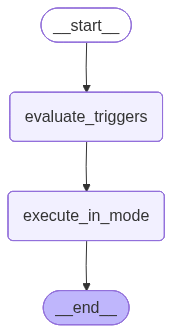

In [17]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("evaluate_triggers", evaluate_triggers_node)
graph_builder.add_node("execute_in_mode",   execute_in_mode_node)

graph_builder.add_edge(START,               "evaluate_triggers")
graph_builder.add_edge("evaluate_triggers", "execute_in_mode")
graph_builder.add_edge("execute_in_mode",   END)

trigger_agent = graph_builder.compile()

# Visualize the two-node structure
display(Image(trigger_agent.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)))

## Running the agent

Running a turn is a single `invoke` call: pass in the conversation history and the current operational metrics, and get back the updated state — new mode, new message, and any trigger log entries from this turn. Each scenario below targets one specific trigger so the routing behavior is easy to trace.

In [18]:
def run_graph_turn(
    messages:         list,
    current_mode:     str   = "chat",
    confidence_score: float = 1.0,
    failure_rate:     float = 0.0,
    risk_metadata:    dict  = None,
    trigger_log:      list  = None,
) -> dict:
    """Run one turn through the trigger-routing agent and return the updated state."""
    return trigger_agent.invoke({
        "messages":         messages,
        "current_mode":     current_mode,
        "confidence_score": confidence_score,
        "failure_rate":     failure_rate,
        "risk_metadata":    risk_metadata or {},
        "trigger_log":      trigger_log or [],
    })


def show_result(result: dict, label: str) -> None:
    """Print a concise summary of one graph invocation."""
    response   = result["messages"][-1].content
    mode       = result["current_mode"]
    log        = result.get("trigger_log", [])
    winners    = [e for e in log if e.get("winner")]
    trigger    = winners[-1]["trigger"] if winners else "none"
    print(f"\n{'─' * 70}")
    print(f"  [{label}]  mode={mode}  trigger={trigger}")
    print(f"  {response[:200]}{'…' if len(response) > 200 else ''}")


# Scenario 1: no trigger fires — stays in chat mode
r1 = run_graph_turn(
    [HumanMessage(content="What are the main differences between REST and GraphQL?")]
)
show_result(r1, "CHAT — no trigger")

# Scenario 2: task-type trigger — "research" keyword detected
r2 = run_graph_turn(
    [HumanMessage(content="Research the top three database indexing strategies.")]
)
show_result(r2, "TASK-TYPE → research")

# Scenario 3: user intent trigger — slash command
r3 = run_graph_turn(
    [HumanMessage(content="/supervised — I want to review each step.")],
    current_mode="task_execution",
)
show_result(r3, "USER INTENT → supervised")

# Scenario 4: risk trigger — destructive keyword in message
r4 = run_graph_turn(
    [HumanMessage(content="Wipe the staging database and start fresh.")],
    current_mode="task_execution",
)
show_result(r4, "RISK → supervised")

# Scenario 5: confidence trigger — agent confidence too low to proceed
r5 = run_graph_turn(
    [HumanMessage(content="Deploy the new schema to production.")],
    current_mode="task_execution",
    confidence_score=0.55,
)
show_result(r5, "CONFIDENCE → supervised")


──────────────────────────────────────────────────────────────────────
  [CHAT — no trigger]  mode=chat  trigger=none
  REST and GraphQL are both ways to interact with APIs, but they have some key differences:

1. **Data Fetching**:
   - **REST**: Uses fixed endpoints for each resource. You might need multiple requests…

──────────────────────────────────────────────────────────────────────
  [TASK-TYPE → research]  mode=research  trigger=task_type_change
  # Top Three Database Indexing Strategies

Database indexing is a critical aspect of database management systems (DBMS) that enhances the speed of data retrieval operations. Here, we will analyze the t…

──────────────────────────────────────────────────────────────────────
  [USER INTENT → supervised]  mode=supervised  trigger=slash_command
  Understood! In supervised mode, I will pause before taking any irreversible actions and explain what I intend to do. This way, you can review each step and provide your approval before I proce

Trigger conditions make mode switching predictable and auditable. Without them, mode changes are either hardcoded or delegated to the LLM's judgment - explicit triggers give us both adaptability and a named, logged reason for every transition.

**Four trigger types, each with a distinct rationale:**

| Trigger | Priority | When it fires | `auto_switch` |
|---|---|---|---|
| Risk | 1 (highest) | Destructive keywords, high scope, PII, high failure rate | `True` - always immediate |
| User Intent | 3 | Slash commands, explicit autonomy phrases | Asymmetric: `True` to reduce, `False` to increase |
| Task-Type | 4 | Inferred intent differs from current mode | `True`, except `task_execution` requires confirmation |
| Confidence | 4 | Agent certainty below threshold | `True` |

- **Priority resolution is deterministic.** When multiple triggers fire, the lowest priority number wins. Ties resolve by evaluation order in the list passed to `evaluate_all_triggers` - document that order as part of the behavioral specification.
- **`auto_switch` encodes an asymmetric safety contract.** Reducing agent autonomy (routing to `supervised`) is always immediate. Increasing it requires explicit confirmation. The safer direction never adds friction for the user.
- **LangGraph separates trigger evaluation from LLM execution.** `evaluate_triggers_node` is a pure function over state and can be unit-tested with no LLM calls at all. `execute_in_mode_node` is the sole place the LLM runs. Inserting a human-approval node for `auto_switch=False` cases requires no changes to either existing node.